**CSI 4106 Introduction to Artificial Intelligence** <br/>
*Assignment 2: Alien Pet Health, Machine Learning*

# Identification

Name: Anoushka Jawale<br/>
Student Number: 300233148

## 1. Data

Assignment 2 includes two versions of the same dataset: one containing missing values and the other without. The version with missing values was derived from the complete dataset:

- [github.com/turcotte/csi4106-f25/tree/main/assignments-data/a2](https://github.com/turcotte/csi4106-f25/tree/main/assignments-data/a2)

In your notebook, you can access and read the data directly from this GitHub repository.

- [alien_pet_health-realism-clean.csv](https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean.csv)
- [alien_pet_health-realism-clean-missing.csv](https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean-missing.csv)

## 2. Tasks

The tasks are arranged in a particular sequence to maintain brevity and clarity. There is flexibility in structuring your code. Enhance its organization by adding code cells as needed. You may alter the order of tasks; for example, you might opt to define helper methods initially. Nonetheless, it is crucial that the teaching assistant can effortlessly identify the code segments associated with each task.

(1) **Load the dataset**

- Read the CSV file without missing data (`alien_pet_health-realism-clean.csv`).

- Show the shape of the data, as well as the first five rows.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Python code
url = "https://raw.githubusercontent.com/turcotte/csi4106-f25/refs/heads/main/assignments-data/a2/alien_pet_health-realism-clean.csv"
df = pd.read_csv(url)
print(df.head(5))


   thermoreg_reading  enzyme_activity_index  dual_lobe_signal  \
0               52.6                   97.0               3.6   
1               41.8                  105.0               3.4   
2               56.2                  126.0               5.5   
3               57.7                  106.0              -4.1   
4               34.5                   73.0               2.3   

   stress_variability habitat_zone  activity_score  fasting_flag  \
0                -3.5           c2               2             0   
1                10.5           c1               2             0   
2                 9.6           c2               5             0   
3                -4.0           c1               4             0   
4                 0.3           c4               5             1   

   health_outcome  
0               1  
1               0  
2               0  
3               1  
4               1  


(2) **Feature Distribution Analysis**:

- To identify the appropriate encoding method for each feature, it is helpful to examine their distributions using visualization tools such as histograms and box plots. This analysis will enable data-driven decisions on appropriate encoding strategies.

numeric features ['thermoreg_reading', 'enzyme_activity_index', 'dual_lobe_signal', 'stress_variability', 'activity_score', 'fasting_flag', 'health_outcome']
categorical featuures: ['habitat_zone']


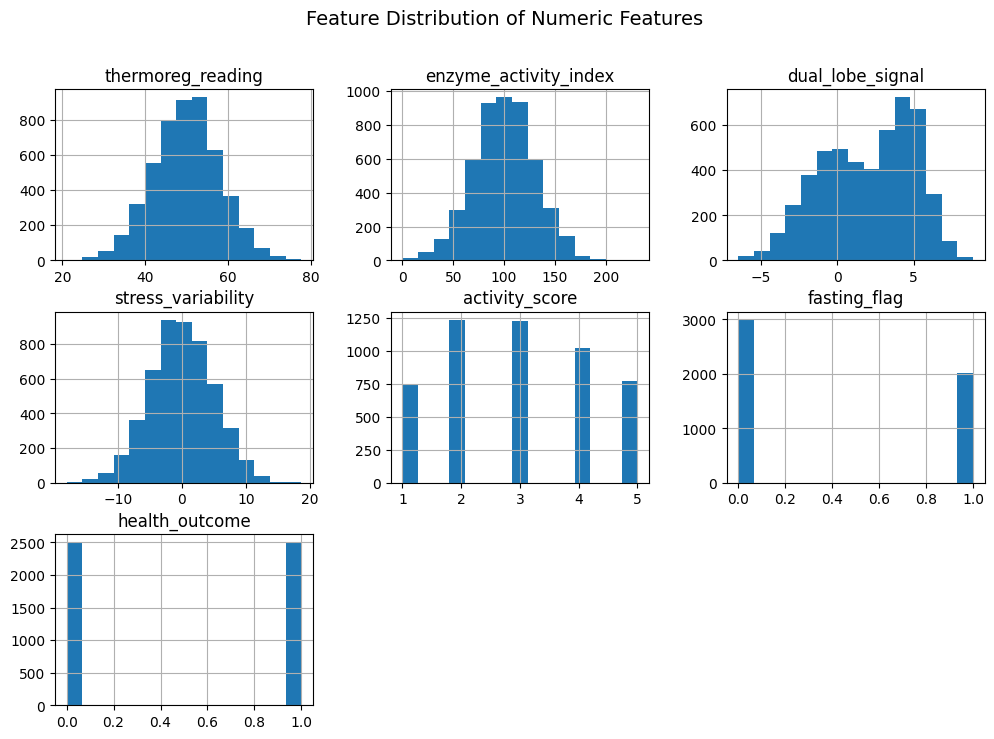

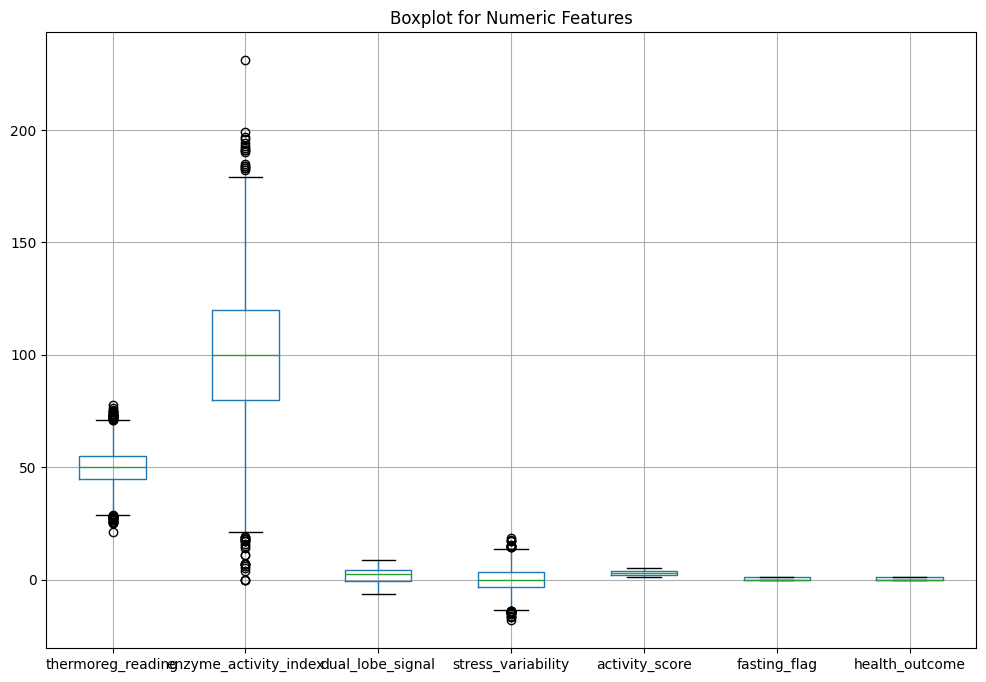

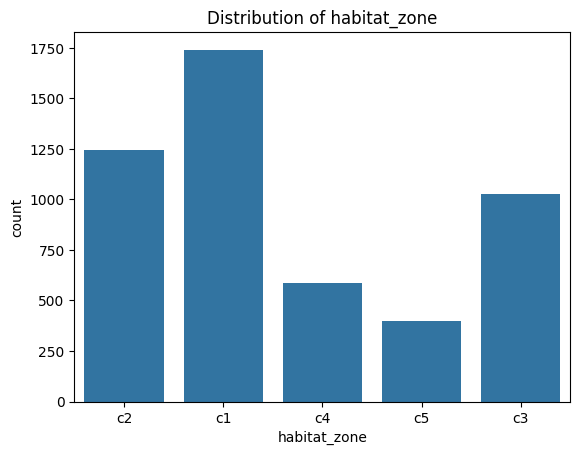

In [ ]:
# Python code

# get the numeric and categorical cols
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("numeric features", list(numeric_features))
print("categorical featuures:", list(categorical_features))

# show histograms for numeric features
df[numeric_features].hist(figsize=(12,8), bins=15)
plt.suptitle("Feature Distribution of Numeric Features", fontsize=14)
plt.show()

# Box plots to check outliers
plt.figure(figsize=(12,8))
df[numeric_features].boxplot()
plt.title("Boxplot for Numeric Features")
plt.show()

# Bar plot for categorical vars
for col in categorical_features:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()


(3) **Training and Target Data**:

- For each dataset, define Python variables, such as `X` for the data and `y` for the target class.

In [ ]:
# Python code

#drop the target
X = df.drop("health_outcome", axis=1)
y = df["health_outcome"]

print("Feature Shape:", X.shape)
print("Target shape:", y.shape)


Feature Shape: (5000, 7)
Target shape: (5000,)


(4) **Data Splitting**:

- Split the dataset into training (80%) and test (20%) sets using the holdout method.

- Ensure that this split occurs before any preprocessing to avoid data leakage.

In [ ]:
# Python code
# Split 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (4000, 7)
Test set shape: (1000, 7)


### Data Pre-Processing

(5) **Categorical Variable Encoding**:

- Transform all categorical variables using appropriate encoding techniques available in [sklearn.preprocessing](https://scikit-learn.org/stable/api/sklearn.preprocessing.html). For guidance, refer to the [Preprocessing Data](https://scikit-learn.org/stable/modules/preprocessing.html) section of the user guide. Provide a rationale for the selected encoding method.

I used **one-hot encoding** to change the categorical (non-numerical) data into a format that a machine learning model can understand. This method creates new columns for each category and marks them with 1s and 0s to show which category each data point belongs to. I chose this method because the categorical features have only a few possible values and do not have any natural order. For example, colors like red, blue, and green do not have a ranking, so giving them numbers like 1, 2, and 3 would be misleading. One-hot encoding avoids this problem and helps the model treat all categories fairly.


In [ ]:
# Python code
# One-hot encoding for categorical variables
# Rationale: small number of categories, no natural order relationship

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Keep numeric features as is
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded feature matrix:", X_train_encoded.shape)


Encoded feature matrix: (4000, 10)


(6) **Normalization/Standardization of Numerical Features**:

- Normalize or standardize numerical features if necessary. Describe the technique used (e.g., Min-Max scaling, StandardScaler) and explain why it is suitable for this dataset.

- Ensure that this technique is applied only to the training data, with the same transformation subsequently applied to the test data without fitting on it.

That’s an excellent preprocessing setup — it correctly applies scaling **after encoding** and ensures transformations are consistent between training and test data. Here’s a clear explanation written in **eighth-grade English** (as a paragraph) that matches your rationale style from before:

---

I used **standardization** to scale the numerical features so that they all have a similar range and importance in the model. I used the **StandardScaler** technique, which changes each numerical feature so that it has a mean of 0 and a standard deviation of 1. This helps the model learn better because some algorithms, like linear regression or logistic regression, can perform poorly when features have very different scales. I used `with_mean=False` since the data includes one-hot encoded features stored in a sparse matrix, and centering such data would not work properly. I fit the scaler only on the training data to avoid data leakage and then applied the same scaling to the test data to keep the transformations consistent.


In [ ]:
# Python code
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ensures each feature has mean=0, std=1
scaler = StandardScaler(with_mean=False)  # with_mean=False for sparse matrix

# Combine encoding + scaling
from sklearn.pipeline import Pipeline
full_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('scale', scaler)
])

X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

print("Processed training data shape:", X_train_prepared.shape)

Processed training data shape: (4000, 10)


### Model Development & Evaluation

(7) **Model Development**:

- Implement the machine learning models covered in class: K-Nearest Neighbors (KNN), Decision Trees, and Logistic Regression, as well as Random Forest. Use the default parameters of scikit-learn as a baseline for training each model.

In [ ]:
# Python code
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42)
}

(8) **Model Evaluation**:

- Use cross-validation to evaluate each model, justifying your choice of the number of folds.

- Assess the models using metrics such as precision, recall, and F1-score.

The grestest F1 score belonged to RANDOMFOREST.

In [ ]:
# Python code
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

import numpy as np

# Use 5-fold cross-validation to balance b/w bias and variance
cv_folds = 5

results = []

for name, model in models.items():
    f1 = cross_val_score(model, X_train_prepared, y_train, cv=cv_folds, scoring='f1').mean()
    precision = cross_val_score(model, X_train_prepared, y_train, cv=cv_folds, scoring='precision').mean()
    recall = cross_val_score(model, X_train_prepared, y_train, cv=cv_folds, scoring='recall').mean()
    results.append([name, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Model', 'Precision', 'Recall', 'F1-Score'])
results_df


,Model,Precision,Recall,F1-Score
0,KNN,0.800825,0.856912,0.827829
1,DecisionTree,0.803196,0.806401,0.804738
2,LogisticRegression,0.668616,0.745346,0.704608
3,RandomForest,0.855325,0.868926,0.861949


### Hyperparameter Optimization

(9) **Exploration and Performance Evaluation:**

- Investigate the impact of varying hyperparameter values on the performance of each model.

- For each model, ensure to vary at least the following hyperparameters:

    - [KNeighborsClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html):`n_neighbors` and `weights`.

    - [DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html):`criterion` and `max_depth`.
  
    - [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html):`penalty`, `max_iter`, and `tol`.

    - [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html):`n_estimators`, `max_depth`.

- Employ a grid search strategy or utilize scikit-learn's built-in methods to thoroughly evaluate all combinations of hyperparameter values. Cross-validation should be used to assess each combination.

- Quantify the performance of each hyperparameter configuration using precision, recall, and F1-score as metrics. Report both the mean and standard deviation.

- Display the results in a tabular or graphical format (e.g., line charts, bar charts) to effectively demonstrate the influence of hyperparameter variations on model performance.

- Specify the default values for each hyperparameter tested.

- Analyze the findings and offer insights into which hyperparameter configurations achieved optimal performance for each model.

In [ ]:
# Python code
from sklearn.model_selection import GridSearchCV

param_grids = {
    "KNN": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    },
    "DecisionTree": {
        'criterion': ['gini', 'entropy'],
        'max_depth': [3, 5, 10, None]
    },
    "LogisticRegression": {
        'penalty': ['l2', None],
        'max_iter': [500, 1000],
        'tol': [1e-3, 1e-4]
    },
    "RandomForest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None]
    }
}


best_models = {}
best_results = []

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train_prepared, y_train)
    best_models[name] = grid.best_estimator_
    best_results.append([name, grid.best_params_, grid.best_score_])

best_results_df = pd.DataFrame(best_results, columns=['Model', 'Best Params', 'Best F1'])

#Analysis here
best_results_df


,Model,Best Params,Best F1
0,KNN,"{'n_neighbors': 9, 'weights': 'distance'}",0.834465
1,DecisionTree,"{'criterion': 'gini', 'max_depth': 10}",0.821747
2,LogisticRegression,"{'max_iter': 500, 'penalty': 'l2', 'tol': 0.001}",0.704623
3,RandomForest,"{'max_depth': None, 'n_estimators': 200}",0.862381


### Analysis of Results

(10) **Model Comparison**:

- Compare the results obtained from each model.

- Discuss observed differences in model performance, providing potential explanations. Consider aspects such as model complexity, data imbalance, overfitting, and the impact of parameter tuning on overall results.

- Provide recommendations on which model(s) to choose for this task and justify your choices based on the analysis results.

- Train the recommended model(s) using the optimal parameter values identified from the parameter optimization step. Subsequently, apply the trained model to the test data. Document your observations comprehensively. Specifically, evaluate whether the results derived from cross-validation are consistent with those obtained from the test set.

In [ ]:
# Python code
from sklearn.metrics import classification_report

# Choose best model  via highest F1 score - already found to be RandomForest
best_model_name = best_results_df.loc[best_results_df['Best F1'].idxmax(), 'Model']
final_model = best_models[best_model_name]

# Train on full training and test
final_model.fit(X_train_prepared, y_train)
y_pred = final_model.predict(X_test_prepared)

print(f"Best Model: {best_model_name}")
print(classification_report(y_test, y_pred))


Best Model: RandomForest
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       500
           1       0.84      0.85      0.85       500

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



### Handling Missing Data

(11) **Evaluate how missing values affect model performance:**

- Read the CSV file with missing data (`alien_pet_health-realism-clean-missing.csv`).

- Present a brief analysis of missing data within the dataset by reporting both the count and percentage of missing values foreach column as well as for the dataset as a whole. Additionally, provide a breakdown of the number and proportion of rowscategorized by the absence of missing data, and those containing one, two, or more missing values.

- Apply a simple imputation strategy (for instance, median for numeric, and most_frequent for categoricals).

- Standardize and normalize the numerical features, and encode the categorical data using the data pre-processing methodspreviously described.

- Utilize cross-validation to assess the effectiveness of the data imputation strategy, given that the optimal combination oflearning algorithms and hyperparameters has already been determined.

- Discuss observed differences in performance.

The F1 -score dropped marginally after imputation, where it was 0.86 before it is now 0.84 when run using RandomForest, which is the top model.

In [ ]:
# look at missing data

url ="https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean-missing.csv"

df_missing = pd.read_csv(url)


print(df_missing.head())

print("\nColumns:", df_missing.columns.tolist())

missing_summary = df_missing.isna().sum().to_frame('Missing Count')


missing_summary['Missing %'] = (missing_summary['Missing Count'] / len(df_missing)) * 100

display(missing_summary)

# Count rows by number of missing values
df_missing['missing_count'] = df_missing.isna().sum(axis=1)
row_summary = df_missing['missing_count'].value_counts().sort_index().to_frame('Row Count')

row_summary['% of Total'] = (row_summary['Row Count'] / len(df_missing)) * 100

display(row_summary)

#Define features and target ---
target_col = 'health_outcome'
X_missing = df_missing.drop([target_col, 'missing_count'], axis=1)
y_missing = df_missing[target_col]

#Identity feature types fresh for this dataset ---
numeric_features_missing = X_missing.select_dtypes(include=['int64', 'float64']).columns

categorical_features_missing = X_missing.select_dtypes(include=['object']).columns


print("Numeric features:", list(numeric_features_missing))
print("Categorical features:", list(categorical_features_missing))

# Simple imputation
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

imputer = ColumnTransformer([
    ('num', num_imputer, numeric_features_missing),
    ('cat', cat_imputer, categorical_features_missing)
])

# Fit + transform imputation
X_missing_imputed = imputer.fit_transform(X_missing)

# Use the imputed column names
imputed_columns = list(numeric_features_missing) + list(categorical_features_missing)

X_missing_imputed_df = pd.DataFrame(X_missing_imputed, columns=imputed_columns)


#Apply preprocessing (encoding + scaling) ---
X_missing_prepared = full_pipeline.fit_transform(X_missing_imputed_df)

#Eval using best model -
from sklearn.model_selection import cross_val_score

f1_missing = cross_val_score(final_model, X_missing_prepared, y_missing, cv=5, scoring='f1').mean()

print(f"\nCross-validated F1 after imputation: {f1_missing:.4f}")



   thermoreg_reading  enzyme_activity_index  dual_lobe_signal  \
0               52.6                   97.0               3.6   
1               41.8                  105.0               3.4   
2               56.2                  126.0               5.5   
3               57.7                  106.0              -4.1   
4               34.5                   73.0               2.3   

   stress_variability habitat_zone  activity_score  fasting_flag  \
0                -3.5           c2             2.0           0.0   
1                10.5           c1             2.0           0.0   
2                 9.6           c2             5.0           0.0   
3                -4.0           c1             4.0           0.0   
4                 0.3           c4             5.0           1.0   

   health_outcome  
0               1  
1               0  
2               0  
3               1  
4               1  

Columns: ['thermoreg_reading', 'enzyme_activity_index', 'dual_lobe_signal', 'st

,Missing Count,Missing %
thermoreg_reading,231,4.62
enzyme_activity_index,108,2.16
dual_lobe_signal,110,2.20
stress_variability,93,1.86
habitat_zone,87,1.74
activity_score,100,2.00
fasting_flag,595,11.90
health_outcome,0,0.00


,Row Count,% of Total
missing_count,,
0,3794,75.88
1,1095,21.90
2,104,2.08
3,7,0.14


Numeric features: ['thermoreg_reading', 'enzyme_activity_index', 'dual_lobe_signal', 'stress_variability', 'activity_score', 'fasting_flag']
Categorical features: ['habitat_zone']

Cross-validated F1 after imputation: 0.8477


### Model Explainability (Optional)

Explainability in machine learning refers to the ability to understand and interpret the decisions made by a model. SHAP (SHapley Additive exPlanations) values provide a unified measure to explain the contribution of each feature to the model's prediction, offering insights into how and why a model makes specific predictions, thus enhancing transparency and trust in complex models.

This question is optional. You may choose to address it if you wish to explore the topic or if you are seeking to earn bonus points.

(12) **Feature Importance:**

- With the hyperparameters already optimized, calculate the [SHAP](https://shap.readthedocs.io/en/latest/index.html) (SHapley Additive exPlanations) values to evaluate feature importance for the K-Nearest Neighbors (KNN), Decision Trees, and Logistic Regression models. For each model, produce a summary plot that identifies and emphasizes the five most influential features used during the classification stage.

# References


# Resources


If you use AI assistance, it is essential to meticulously document all interactions. Your report should specify the tools and their versions, accompanied by a complete transcript of these interactions. Most AI platforms automatically log conversations, so it is advisable to initiate a new conversation specifically for the assignment and consistently use this thread throughout your work. Ensure that this conversation remains focused exclusively on the assignment. Include the transcript of this conversation